In [2]:

'''
Imputation of the missing values
Using same columns values to refill the missing values is called univariate 
If you are using the other columns to refill the value then called as multivariate
Multivariate has two types to do KNN and iterative 
'''

'\nImputation of the missing values\nUsing same columns values to refill the missing values is called univariate \nIf you are using the other columns to refill the value then called as multivariate\nMultivariate has two types to do KNN and iterative \n'

In [3]:
#Mean and Median Imputation
'''
Prefer If data distribution is normal then go for mean and if , 
Data is skewed so go for the medain as the mean gets shifted

We should use it when Data is MCAR (missing at random),
This method is prefered if the values missing are less than 5%

In this method distibution shape changes and sysytem gets some outliers,
we get some changes is covariance and corelation

can perform tis from sklearn ad pandas but sklearn prefreable as its simple at the time of production
'''

'\nPrefer If data distribution is normal then go for mean and if , \nData is skewed so go for the medain as the mean gets shifted\n\nWe should use it when Data is MCAR (missing at random),\nThis method is prefered if the values missing are less than 5%\n\nIn this method distibution shape changes and sysytem gets some outliers,\nwe get some changes is covariance and corelation\n\ncan perform tis from sklearn ad pandas but sklearn prefreable as its simple at the time of production\n'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [5]:
df = pd.read_csv('Datasets/titanic_toy.csv')

In [6]:
df.sample(5)

,Age,Fare,Family,Survived
868,NaN,9.5000,0,0
658,23.0,13.0000,0,0
503,37.0,9.5875,0,0
363,35.0,7.0500,0,0
519,32.0,7.8958,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [8]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [10]:
X_train.isnull().mean()


Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [11]:
#now  as it is noticed as the fare column has 5% values missing so this method is good,
#and how the other column has every red flag after this method

mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [12]:
#filling the missing values with mean and median using pandas 
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)


In [13]:
X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
103,33.0,8.6542,0,33.00,33.000000,8.6542,8.654200
380,42.0,227.5250,0,42.00,42.000000,227.5250,227.525000
8,27.0,11.1333,2,27.00,27.000000,11.1333,11.133300
328,31.0,20.5250,2,31.00,31.000000,20.5250,20.525000
82,NaN,NaN,0,28.75,29.785904,14.4583,32.617597


In [14]:
#Now will check how the data is affect on the variance(it will be low from orignal but there should be not much difference)
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_mean'].var())

#Noticable that the fare column has not much difference in orignal and mean, medain difference


Original Age variable variance:  204.34951339046142
Age Variance after median imputation:  161.98956633460548
Age Variance after mean imputation:  161.81262452718676
Original Fare variable variance:  2448.1979137063163
Fare Variance after median imputation:  2340.09102197536
Fare Variance after mean imputation:  2324.2385256705534


<Axes: ylabel='Density'>

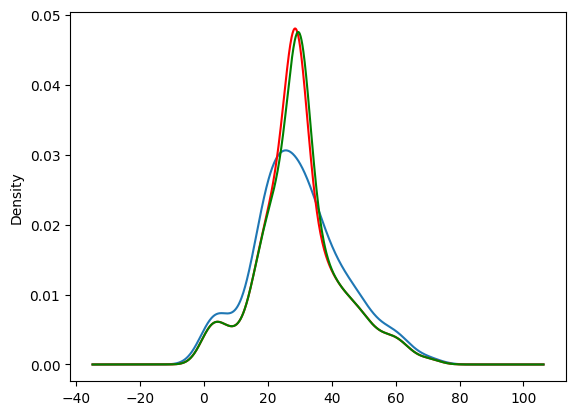

In [15]:
#Now the grpah of the age before and after the mean, median imputation
fig = plt.figure()
ax = fig.add_subplot(111)

#Orignal age Distribution 
X_train['Age'].plot(kind = 'kde', ax = ax)
#Age vaiable imputed with median
X_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'red')
#Age variable imputed with mean
X_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'green')

<Axes: ylabel='Density'>

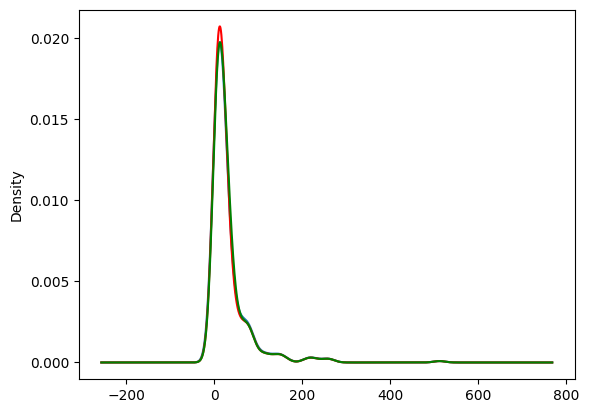

In [16]:
#Now the grpah of the Fare before and after the mean, median imputation and its noticable that there is minimal change in distribution
fig = plt.figure()
ax = fig.add_subplot(111)

#Orignal Fare Distribution 
X_train['Fare'].plot(kind = 'kde', ax = ax)
#Fare vaiable imputed with median
X_train['Fare_median'].plot(kind = 'kde', ax = ax, color = 'red')
#Fare variable imputed with mean
X_train['Fare_mean'].plot(kind = 'kde', ax = ax, color = 'green')




<Axes: >

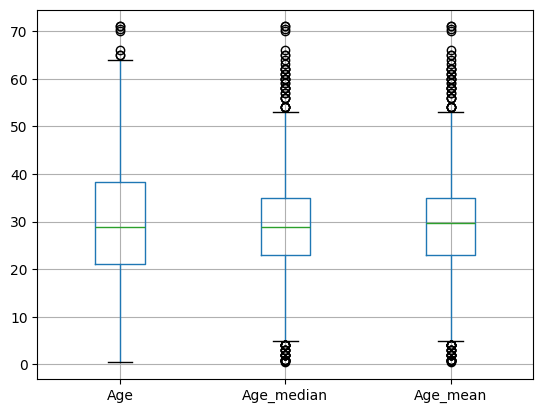

In [17]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()
#there are more outliers in age mean and median as they are not the outliers as data is more mean centric


<Axes: >

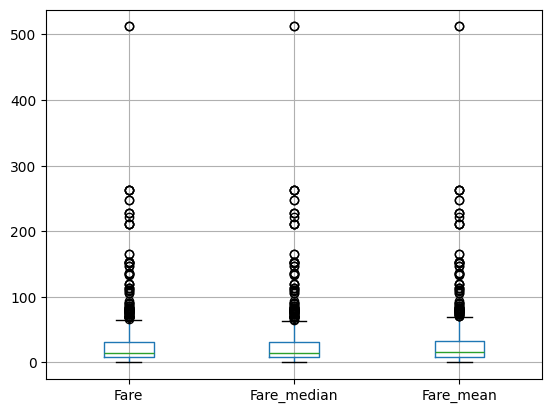

In [18]:
X_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()
#this show that  there is not much change in the fare outliers almost minimal 


In [19]:
'''
From these we can check which method is best for the missing value replacement
'''

'\nFrom these we can check which method is best for the missing value replacement\n'

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [21]:
#Using Sklearn by simpleImputer class

imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [22]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
])

In [23]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [24]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [25]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [26]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)


In [27]:
X_train


array([[ 40.    ,  27.7208],
       [  4.    ,  16.7   ],
       [ 47.    ,   9.    ],
       ...,
       [ 71.    ,  49.5042],
       [ 28.75  , 221.7792],
       [ 28.75  ,  25.925 ]], shape=(712, 2))